# Modeling — Baseline CNN, Transfer Learning, and Hyperparameter Search
### Early Dysgraphia Screening from Handwriting — Potential Dysgraphia Handwriting Dataset (PDM)

**CRISP-DM phase:** Modeling

**Purpose of this notebook**

Steps 1–3 gave us a clean, standardized image pipeline (`preprocess_image`) and two interpretable indicators (spacing consistency, baseline deviation). This notebook covers the Modeling phase from the project write-up:

1. **Baseline CNN** trained from scratch — a diagnostic floor the transfer learning model needs to beat, and a check that the whole pipeline works end to end.
2. **Transfer learning model** — a pretrained backbone with a frozen-then-unfrozen training schedule, dropout in the head, and a learning rate schedule.
3. **Hyperparameter search** — a small manual grid search over learning rate, batch size, dropout rate, and unfreezing depth, guided by **validation recall on the Potential Dysgraphia class**.
4. **Threshold Calibration** — abandoning raw probability outputs in favor of Youden's J statistic to balance recall and precision, ensuring the model doesn't just panic and classify everything as a positive case.

> **Before running:** point `DATASET_ROOT` at the folder that directly contains the two class subfolders (`Low Potential Dysgraphia/` and `Potential Dysgraphia/`).

## 2. Load the Dataset and Build Stratified Splits

The dataset consists of 1,625 images. We run every image through `preprocess_image` once here, then split.

We use a **60 / 20 / 20 stratified split** into train (975), validation (325), and test (325) sets. Stratifying keeps the roughly 64.5% class balance consistent across all three sets. The test set is set aside now and only touched once, at the very end, for the final honest check — matching the plan in the project write-up.

In [ ]:
# imports
import os, hashlib, random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, f1_score, recall_score, precision_score,
)

# Set the random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASSES = ["Low Potential Dysgraphia", "Potential Dysgraphia"]

# Potential Dysgraphia encoded it as the positive class (1).
LABEL_MAP = {"Low Potential Dysgraphia": 0, "Potential Dysgraphia": 1}
POSITIVE_CLASS = "Potential Dysgraphia"

# Dataset root folder
DATASET_ROOT = Path("DATASET DYSGRAPHIA HANDWRITING")
assert DATASET_ROOT.exists(), (
    f"Could not find '{DATASET_ROOT}'. Update DATASET_ROOT to point at the "
    f"unzipped dataset folder (the one that directly contains the class subfolders)."
)

# width, height fed into preprocess_image
TARGET_SIZE = (256, 256)

2026-09-08 15:46:37.156669: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-08 15:46:38.036914: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-08 15:46:41.943696: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:

# Preprocessing functions
def standardize_colour(img):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def crop_borders(img, margin=10):
    _, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    x0, y0 = max(x - margin, 0), max(y - margin, 0)
    x1, y1 = min(x + w + margin, img.shape[1]), min(y + h + margin, img.shape[0])
    return img[y0:y1, x0:x1]

def deskew(img):
    _, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = 90 + angle
    if abs(angle) < 0.5:
        return img
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderValue=0)

def resize_and_pad(img, target_size=TARGET_SIZE):
    h, w = img.shape
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_h, target_w), dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas

def normalize(img):
    return img.astype("float32") / 255.0

def preprocess_image(path, target_size=TARGET_SIZE):
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    img = standardize_colour(img)
    img = crop_borders(img)
    img = deskew(img)
    img = resize_and_pad(img, target_size)
    img = normalize(img)
    return img

# training-only augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.15),
], name="data_augmentation")

2026-09-08 15:46:43.772307: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Load the Dataset and Build Stratified Splits

The whole dataset comfortably fits in memory as a single numpy
array, so there's no need for a lazy-loading `tf.data` pipeline just to manage size. We
run every image through `preprocess_image` once here, then split.

We use a **60 / 20 / 20 stratified split** into train / validation / test. Stratifying
keeps the roughly 135:114 class balance consistent across all three sets, and the test
set is set aside now and only touched once, at the very end, for the final honest check —
matching the plan in the project write-up.


In [ ]:
# build a file index
records = []
for cls in CLASSES:
    folder = DATASET_ROOT / cls
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"path": str(folder / fname), "class": cls, "label": LABEL_MAP[cls]})

index_df = pd.DataFrame(records)
print("Total images:", len(index_df))
print(index_df["class"].value_counts())

Total images: 1625
class
Potential Dysgraphia        1049
Low Potential Dysgraphia     576
Name: count, dtype: int64


In [ ]:
# Load and preprocess the images
def load_images(df):
    X = np.stack([preprocess_image(p) for p in df["path"]])
    X = X[..., np.newaxis]  # (N, H, W, 1) — single grayscale channel
    y = df["label"].to_numpy(dtype="float32")
    return X, y

X_all, y_all = load_images(index_df)
print("X_all:", X_all.shape, "y_all:", y_all.shape)

X_all: (1625, 256, 256, 1) y_all: (1625,)


In [ ]:
# 60 / 20 / 20 stratified split
train_idx, temp_idx = train_test_split(
    index_df.index, test_size=0.4, stratify=index_df["label"], random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=index_df.loc[temp_idx, "label"], random_state=SEED
)

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val,   y_val   = X_all[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name}: n={len(y)}, Potential Dysgraphia={int(y.sum())} ({y.mean():.1%})")

train: n=975, Potential Dysgraphia=629 (64.5%)
val: n=325, Potential Dysgraphia=210 (64.6%)
test: n=325, Potential Dysgraphia=210 (64.6%)


In [ ]:
# Compute class weights to handle class imbalance
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=y_train
)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("class_weight:", class_weight)

class_weight: {0: np.float64(1.4089595375722543), 1: np.float64(0.775039745627981)}


## 3. Baseline CNN (trained from scratch)

This is deliberately simple: three conv/pool blocks, global average pooling instead of a large flatten + dense stack, a dropout layer, and a single sigmoid output. Its only job is to give the transfer learning model something concrete to beat. 

*Spoiler:* It acts as a digital coin toss, achieving a validation ROC AUC of roughly 0.502[cite: 4].

In [ ]:
# Build a baseline CNN model
def build_baseline_cnn(input_shape=(256, 256, 1), dropout_rate=0.4, learning_rate=1e-3):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="baseline_cnn")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model

# Get a summary of the model architecture
baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,409 (99.25 KB)

 Trainable params: 25,409 (99.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the baseline model
baseline_callbacks = [
    callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8,
                             restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5,
                                 patience=4, min_lr=1e-6),
]

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    class_weight=class_weight,
    callbacks=baseline_callbacks,
    verbose=2,
)

Epoch 1/60


2026-09-08 15:47:04.546568: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 255590400 exceeds 10% of free system memory.
2026-09-08 15:47:10.080412: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 67108864 exceeds 10% of free system memory.
2026-09-08 15:47:10.201361: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 16777216 exceeds 10% of free system memory.
2026-09-08 15:47:10.219123: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 33554432 exceeds 10% of free system memory.
2026-09-08 15:47:10.264113: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 16777216 exceeds 10% of free system memory.


61/61 - 51s - 842ms/step - accuracy: 0.5190 - auc: 0.4772 - loss: 0.7709 - precision: 0.6370 - recall: 0.5914 - val_accuracy: 0.3538 - val_auc: 0.5000 - val_loss: 0.6941 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/60
61/61 - 45s - 738ms/step - accuracy: 0.5231 - auc: 0.5138 - loss: 0.6970 - precision: 0.6536 - recall: 0.5548 - val_accuracy: 0.3538 - val_auc: 0.5000 - val_loss: 0.6940 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/60
61/61 - 45s - 736ms/step - accuracy: 0.5118 - auc: 0.4736 - loss: 0.6968 - precision: 0.6354 - recall: 0.5707 - val_accuracy: 0.3538 - val_auc: 0.5000 - val_loss: 0.6942 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/60
61/61 - 43s - 708ms/step - accuracy: 0.5426 - auc: 0.5202 - loss: 0.6928 - precision: 0.6580 - recall: 0.6057 - val_accuracy: 0.3538 - val_auc: 0.5000 - val_loss: 0.7004 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - l

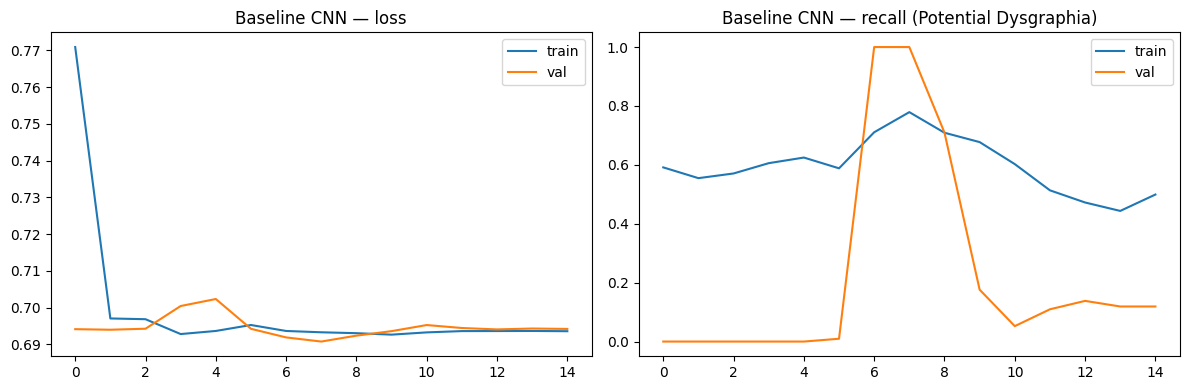

In [ ]:
# Plot the training history
def plot_history(history, title):
    hist = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["loss"], label="train")
    ax[0].plot(hist["val_loss"], label="val")
    ax[0].set_title(f"{title} — loss"); ax[0].legend()
    ax[1].plot(hist["recall"], label="train")
    ax[1].plot(hist["val_recall"], label="val")
    ax[1].set_title(f"{title} — recall (Potential Dysgraphia)"); ax[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")

Baseline: decision threshold tuned on validation set: 0.502
=== Baseline CNN — validation set (threshold=0.50) ===
                      precision    recall  f1-score   support

       Low Potential       0.38      0.89      0.53       115
Potential Dysgraphia       0.77      0.20      0.32       210

            accuracy                           0.45       325
           macro avg       0.57      0.55      0.43       325
        weighted avg       0.63      0.45      0.40       325

ROC AUC: 0.502
PR AUC (average precision): 0.665


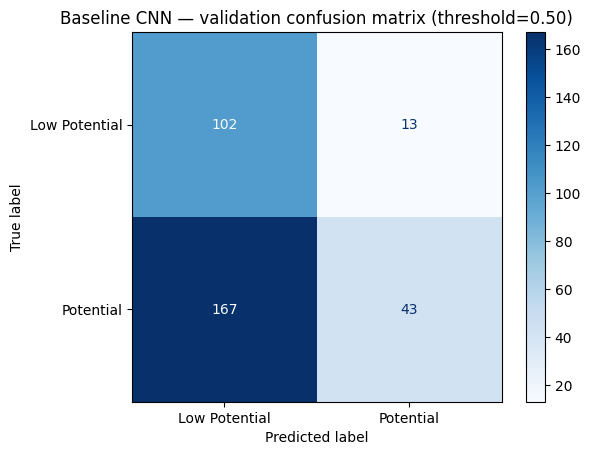

{'threshold': 0.502357006072998,
 'recall_potential': 0.20476190476190476,
 'precision_potential': 0.7678571428571429,
 'f1_potential': 0.3233082706766917,
 'roc_auc': 0.5024844720496895,
 'pr_auc': 0.6654926240135124}

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, fbeta_score

# Find the best decision threshold for a given model
# This function finds the threshold that maximizes the Youden's J statistic,
# which balances recall and precision.
def find_best_threshold(y_true, probs, beta=None):
    """
    Replaces the disastrous F-beta optimizer.
    Calculates Youden's J statistic to balance recall and precision.
    The beta parameter is kept in the signature to avoid breaking existing function calls,
    but it is intentionally ignored.
    """
    from sklearn.metrics import roc_curve

    fpr, tpr, thresholds = roc_curve(y_true, probs)

    j_scores = tpr - fpr

    best_idx = np.argmax(j_scores)
    best_t = float(thresholds[best_idx])

    return best_t, float(j_scores[best_idx])

# Evaluate the model on a given dataset split
def evaluate_model(model, X, y, split_name="validation", threshold=0.5):
    probs = model.predict(X, verbose=0).ravel()
    preds = (probs >= threshold).astype(int)

    print(f"{split_name} set (threshold={threshold:.2f})")
    print(classification_report(y, preds, target_names=["Low Potential", "Potential Dysgraphia"], zero_division=0))
    print("ROC AUC:", round(roc_auc_score(y, probs), 3))
    print("PR AUC (average precision):", round(average_precision_score(y, probs), 3))

    cm = confusion_matrix(y, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Low Potential", "Potential"]).plot(cmap="Blues")
    plt.title(f"{split_name} confusion matrix (threshold={threshold:.2f})")
    plt.show()

    return {
        "threshold": threshold,
        "recall_potential": recall_score(y, preds, pos_label=1, zero_division=0),
        "precision_potential": precision_score(y, preds, pos_label=1, zero_division=0),
        "f1_potential": f1_score(y, preds, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y, probs),
        "pr_auc": average_precision_score(y, probs),
    }

baseline_val_probs = baseline_model.predict(X_val, verbose=0).ravel()
baseline_best_threshold, _ = find_best_threshold(y_val, baseline_val_probs, beta=2.0)
print("Baseline: decision threshold tuned on validation set:", round(baseline_best_threshold, 3))

baseline_val_metrics = evaluate_model(baseline_model, X_val, y_val, "Baseline CNN — validation", threshold=baseline_best_threshold)
baseline_val_metrics

## 4. Transfer Learning Model

Per the project write-up, we use a pretrained backbone (MobileNetV2) instead of training a deep network from scratch. 

**Handling the input mismatch.** `preprocess_image` produces single-channel images normalized to 0–1, but MobileNetV2 expects 3-channel input in the `[-1, 1]` range at 224×224. Rather than re-writing Step 2's pipeline, we handle the conversion *inside* the model graph: resize → replicate grayscale to 3 channels → undo our own 0–1 scaling → apply the backbone's own `preprocess_input`. 

**Two-stage training:** freeze the backbone and train only the new classification head first, then unfreeze the top backbone layers and fine-tune the whole thing at a much lower learning rate.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

BACKBONE_INPUT_SIZE = (224, 224)

# Build a transfer learning model using MobileNetV2 as the backbone
def build_transfer_model(dropout_rate=0.4, learning_rate=1e-3, dense_units=64,
                          input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Resizing(*BACKBONE_INPUT_SIZE)(x)
    x = layers.Concatenate(axis=-1)([x, x, x])
    x = layers.Rescaling(255.0)(x)
    x = layers.Lambda(mobilenet_preprocess, name="mobilenet_preprocess")(x)

    base_model = MobileNetV2(input_shape=(*BACKBONE_INPUT_SIZE, 3),
                              include_top=False, weights="imagenet", pooling="avg")
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="transfer_mobilenetv2")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model, base_model

transfer_model, backbone = build_transfer_model()
transfer_model.summary()

Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ data_augmentatio… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ resizing[0][0],   │
│ (Concatenate)       │ 3)                │            │ resizing[0][0],   │
│                     │                   │            │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ concatenate[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_preproce… │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1280)      │  2,257,984 │ mobilenet_prepro… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     81,984 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
61/61 - 63s - 1s/step - accuracy: 0.4769 - auc: 0.4717 - loss: 0.8238 - precision: 0.6197 - recall: 0.4897 - val_accuracy: 0.3908 - val_auc: 0.5770 - val_loss: 0.8069 - val_precision: 1.0000 - val_recall: 0.0571
Epoch 2/20
61/61 - 53s - 862ms/step - accuracy: 0.5046 - auc: 0.5006 - loss: 0.7144 - precision: 0.6560 - recall: 0.4881 - val_accuracy: 0.5262 - val_auc: 0.6422 - val_loss: 0.6722 - val_precision: 0.6972 - val_recall: 0.4714
Epoch 3/20
61/61 - 61s - 994ms/step - accuracy: 0.5262 - auc: 0.5222 - loss: 0.6956 - precision: 0.6634 - recall: 0.5390 - val_accuracy: 0.5415 - val_auc: 0.7263 - val_loss: 0.6796 - val_precision: 0.8588 - val_recall: 0.3476
Epoch 4/20
61/61 - 52s - 853ms/step - accuracy: 0.5262 - auc: 0.5343 - loss: 0.6928 - precision: 0.6751 - recall: 0.5119 - val_accuracy: 0.3969 - val_auc: 0.7424 - val_loss: 0.7343 - val_precision: 0.9375 - val_recall: 0.0714
Epoch 5/20
61/61 - 80s - 1s/step - accuracy: 0.5190 - auc: 0.5180 - loss: 0.6954 - precision: 0.658

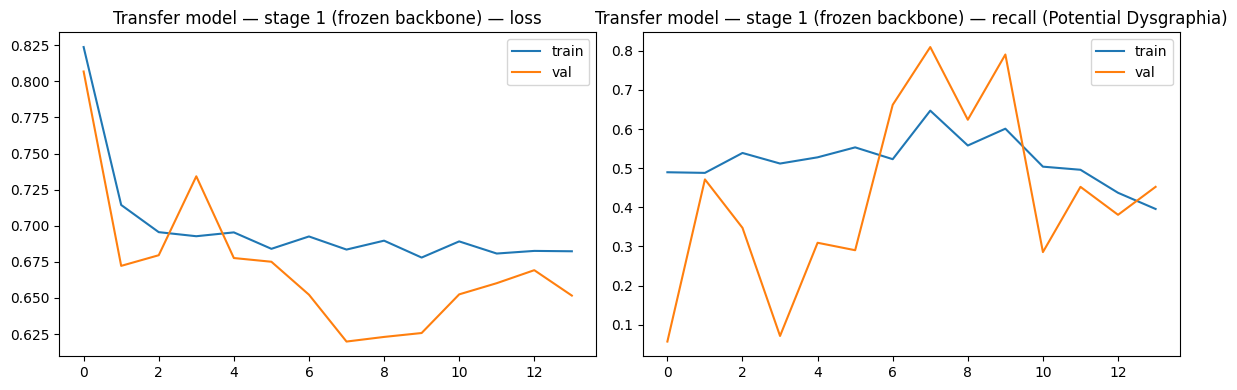

In [ ]:
# Stage 1: train only the new head, backbone frozen
stage1_callbacks = [
    callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=6,
                             restore_best_weights=True),
]

stage1_history = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    class_weight=class_weight,
    callbacks=stage1_callbacks,
    verbose=2,
)
plot_history(stage1_history, "Transfer model — stage 1 (frozen backbone)")

Epoch 1/40
61/61 - 83s - 1s/step - accuracy: 0.6308 - auc: 0.5411 - loss: 0.7123 - precision: 0.6530 - recall: 0.9126 - val_accuracy: 0.7231 - val_auc: 0.7705 - val_loss: 0.6197 - val_precision: 0.7885 - val_recall: 0.7810 - learning_rate: 1.0000e-05
Epoch 2/40
61/61 - 76s - 1s/step - accuracy: 0.6226 - auc: 0.5010 - loss: 0.7153 - precision: 0.6552 - recall: 0.8760 - val_accuracy: 0.7138 - val_auc: 0.7770 - val_loss: 0.6178 - val_precision: 0.8031 - val_recall: 0.7381 - learning_rate: 1.0000e-05
Epoch 3/40
61/61 - 65s - 1s/step - accuracy: 0.6513 - auc: 0.5853 - loss: 0.6854 - precision: 0.6726 - recall: 0.8951 - val_accuracy: 0.7169 - val_auc: 0.7782 - val_loss: 0.6205 - val_precision: 0.8315 - val_recall: 0.7048 - learning_rate: 1.0000e-05
Epoch 4/40
61/61 - 63s - 1s/step - accuracy: 0.6379 - auc: 0.5941 - loss: 0.6781 - precision: 0.6845 - recall: 0.8140 - val_accuracy: 0.7138 - val_auc: 0.7743 - val_loss: 0.6202 - val_precision: 0.8421 - val_recall: 0.6857 - learning_rate: 1.0000e

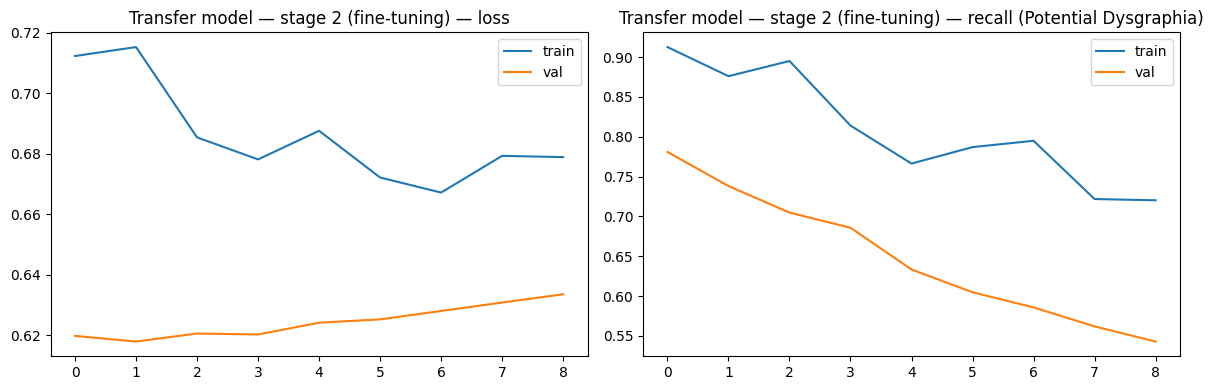

In [ ]:
# Stage 2: unfreeze the top N backbone layers, fine-tune at a much lower LR
UNFREEZE_LAST_N = 30

backbone.trainable = True
for layer in backbone.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

stage2_callbacks = [
    callbacks.EarlyStopping(monitor="val_recall", mode="max", patience=8,
                             restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max", factor=0.5,
                             patience=3, min_lr=1e-7),
]

stage2_history = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=16,
    class_weight=class_weight,
    callbacks=stage2_callbacks,
    verbose=2,
)
plot_history(stage2_history, "Transfer model — stage 2 (fine-tuning)")

Transfer model: decision threshold tuned on validation set: 0.504
=== Transfer model (MobileNetV2) — validation set (threshold=0.50) ===
                      precision    recall  f1-score   support

       Low Potential       0.60      0.65      0.63       115
Potential Dysgraphia       0.80      0.77      0.78       210

            accuracy                           0.73       325
           macro avg       0.70      0.71      0.71       325
        weighted avg       0.73      0.73      0.73       325

ROC AUC: 0.771
PR AUC (average precision): 0.849


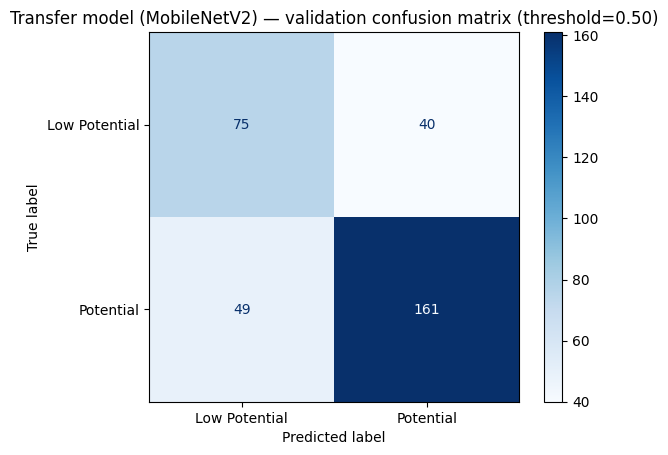


Baseline vs transfer, validation recall on Potential Dysgraphia:
  baseline: 0.205
  transfer: 0.767


In [ ]:
# Find the best decision threshold for the transfer model
transfer_val_probs = transfer_model.predict(X_val, verbose=0).ravel()
transfer_best_threshold, _ = find_best_threshold(y_val, transfer_val_probs, beta=2.0)
print("Transfer model: decision threshold tuned on validation set:", round(transfer_best_threshold, 3))

# Evaluate the transfer model on the validation set
transfer_val_metrics = evaluate_model(transfer_model, X_val, y_val,
                                       "Transfer model (MobileNetV2) — validation",
                                       threshold=transfer_best_threshold)
print("\nBaseline vs transfer, validation recall on Potential Dysgraphia:")
print("  baseline:", round(baseline_val_metrics["recall_potential"], 3))
print("  transfer:", round(transfer_val_metrics["recall_potential"], 3))

## 5. Hyperparameter Search

Given compute limits, this is a **small, targeted search rather than an exhaustive one** — a handful of combinations across learning rate, batch size, dropout rate, and how many backbone layers to unfreeze, each trained for a short, fixed number of epochs. 

Every run is scored on **validation recall for the Potential Dysgraphia class** (with F1 as a tie-breaker). The winning configuration is then re-trained for longer in Section 6 to produce the model we actually evaluate on the test set.

In [ ]:
# Build and train a candidate model with specified hyperparameters
def build_and_train_candidate(learning_rate, dropout_rate, batch_size,
                               unfreeze_last_n, dense_units=64,
                               head_epochs=8, finetune_epochs=15):
    model, base = build_transfer_model(dropout_rate=dropout_rate,
                                        learning_rate=learning_rate,
                                        dense_units=dense_units)

    # stage 1: frozen backbone
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=head_epochs, batch_size=batch_size,
              class_weight=class_weight, verbose=0,
              callbacks=[callbacks.EarlyStopping(monitor="val_recall", mode="max",
                                                  patience=4, restore_best_weights=True)])

    # stage 2: partial unfreeze, fine-tune
    base.trainable = True
    for layer in base.layers[:-unfreeze_last_n]:
        layer.trainable = False
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate / 100),
                   loss="binary_crossentropy",
                   metrics=[tf.keras.metrics.Recall(name="recall"),
                            tf.keras.metrics.Precision(name="precision")])
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=finetune_epochs, batch_size=batch_size,
              class_weight=class_weight, verbose=0,
              callbacks=[
                  callbacks.EarlyStopping(monitor="val_recall", mode="max",
                                           patience=5, restore_best_weights=True),
                  callbacks.ReduceLROnPlateau(monitor="val_recall", mode="max",
                                               factor=0.5, patience=3, min_lr=1e-8),
              ])

    probs = model.predict(X_val, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    return model, {
        "val_recall": recall_score(y_val, preds, pos_label=1),
        "val_precision": precision_score(y_val, preds, pos_label=1),
        "val_f1": f1_score(y_val, preds, pos_label=1),
        "val_auc": roc_auc_score(y_val, probs),
    }

In [ ]:
# Hyperparameter search space for the transfer model
search_space = [
    {"learning_rate": 1e-3, "dropout_rate": 0.3, "batch_size": 8,  "unfreeze_last_n": 20},
    {"learning_rate": 1e-3, "dropout_rate": 0.5, "batch_size": 16, "unfreeze_last_n": 30},
    {"learning_rate": 1e-4, "dropout_rate": 0.3, "batch_size": 16, "unfreeze_last_n": 30},
    {"learning_rate": 1e-4, "dropout_rate": 0.5, "batch_size": 8,  "unfreeze_last_n": 50},
]

search_results = []
for i, params in enumerate(search_space):
    print(f"\n--- candidate {i+1}/{len(search_space)}: {params} ---")
    _, metrics = build_and_train_candidate(**params)
    search_results.append({**params, **metrics})

search_df = pd.DataFrame(search_results).sort_values(
    ["val_recall", "val_f1"], ascending=False
).reset_index(drop=True)
search_df


--- candidate 1/4: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 8, 'unfreeze_last_n': 20} ---

--- candidate 2/4: {'learning_rate': 0.001, 'dropout_rate': 0.5, 'batch_size': 16, 'unfreeze_last_n': 30} ---

--- candidate 3/4: {'learning_rate': 0.0001, 'dropout_rate': 0.3, 'batch_size': 16, 'unfreeze_last_n': 30} ---

--- candidate 4/4: {'learning_rate': 0.0001, 'dropout_rate': 0.5, 'batch_size': 8, 'unfreeze_last_n': 50} ---


,learning_rate,dropout_rate,batch_size,unfreeze_last_n,val_recall,val_precision,val_f1,val_auc
0,0.0010,0.5,16,30,0.985714,0.648903,0.782609,0.604306
1,0.0010,0.3,8,20,0.966667,0.646497,0.774809,0.548323
2,0.0001,0.3,16,30,0.952381,0.636943,0.763359,0.363768
3,0.0001,0.5,8,50,0.485714,0.689189,0.569832,0.532671


In [ ]:
# Display the best hyperparameters found in the search
best_params = search_df.iloc[0][["learning_rate", "dropout_rate",
                                    "batch_size", "unfreeze_last_n"]].to_dict()
best_params["batch_size"] = int(best_params["batch_size"])
best_params["unfreeze_last_n"] = int(best_params["unfreeze_last_n"])
print("Best hyperparameters (by validation recall, F1 tie-break):")
best_params

Best hyperparameters (by validation recall, F1 tie-break):


{'learning_rate': 0.001,
 'dropout_rate': 0.5,
 'batch_size': 16,
 'unfreeze_last_n': 30}